<a href="https://colab.research.google.com/github/JSEFERINO/Analisis-de-Datos-con-Python-2020/blob/master/laboratorio_8_intervalos_de_confianza_jesmen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **laboratorio 8 - intervalos de confianza - parte 2**
# **Estadistica inferencial - INTERVALOS DE CONFIANZA PARA DIFERENCIA DE MEDIAS Y COCIENTE DE VARIANZAS**
## **Jesus Mendoza**
> Email: jesuyagami1@gmail.com

> Celular: 3007620184

> Código Estudiantil - T00076522


**link - https://rpubs.com/jseferino/1413904**

# **Librerias para Trabar en R**

In [ ]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [CASO 1: VARIANZAS CONOCIDAS](#T1)
## **2.** [CÓDIGO R - INTERVALO DE CONFIANZA CON VARIANZAS CONOCIDAS](#T2)

## **3.** [CASO 2: VARIANZAS DESCONOCIDAS PERO IGUALES](#T3)

## **4.** [CÓDIGO R - VARIANZAS DESCONOCIDAS PERO IGUALES](#T4)

## **5.** [CASO 3: VARIANZAS DESCONOCIDAS Y DIFERENTES](#T5)

## **6.** [CASO 4: COCIENTE DE VARIANZAS (PRUEBA F)](#T6)

## **7.** [g](#T7)


## **8.** [h](#T8)

## **9.** [i](#T9)


## **10.** [j](#T10)

## **11.** [k](#T11)

## **12.** [l](#T12)

## **13.** [m](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. CASO 1: VARIANZAS CONOCIDAS - Contexto: Ingeniería Industrial - Control de Calidad en Producción**

**PROBLEMA: Comparación de Tiempos de Producción
Una planta de ensamblaje automotriz evalúa si dos líneas de producción (Línea A y Línea B) tienen tiempos promedio de ensamblaje diferentes. Se conocen las varianzas poblacionales por estudios previos: σ₁² = 4.5 min² y σ₂² = 5.2 min². Se toman muestras pequeñas de n₁ = 12 y n₂ = 10 vehículos.**

CASO 1: INTERVALO DE CONFIANZA - VARIANZAS CONOCIDAS

📊 Estadísticos muestrales:
   Media Línea A (x̄₁): 9.1278 minutos
   Media Línea B (x̄₂): 6.4916 minutos
   Diferencia observada: 2.6362 minutos

📈 Cálculos:
   Error estándar: 0.9460
   Z crítico (95%): ±1.9600

🎯 Intervalo de Confianza (95%):
   (0.7820, 4.4904) minutos

💡 Interpretación:
   Con un 95% de confianza, la verdadera diferencia de tiempos
   se encuentra entre 0.7820 y 4.4904 minutos.
   → El intervalo NO contiene 0. Las diferencias son significativas.


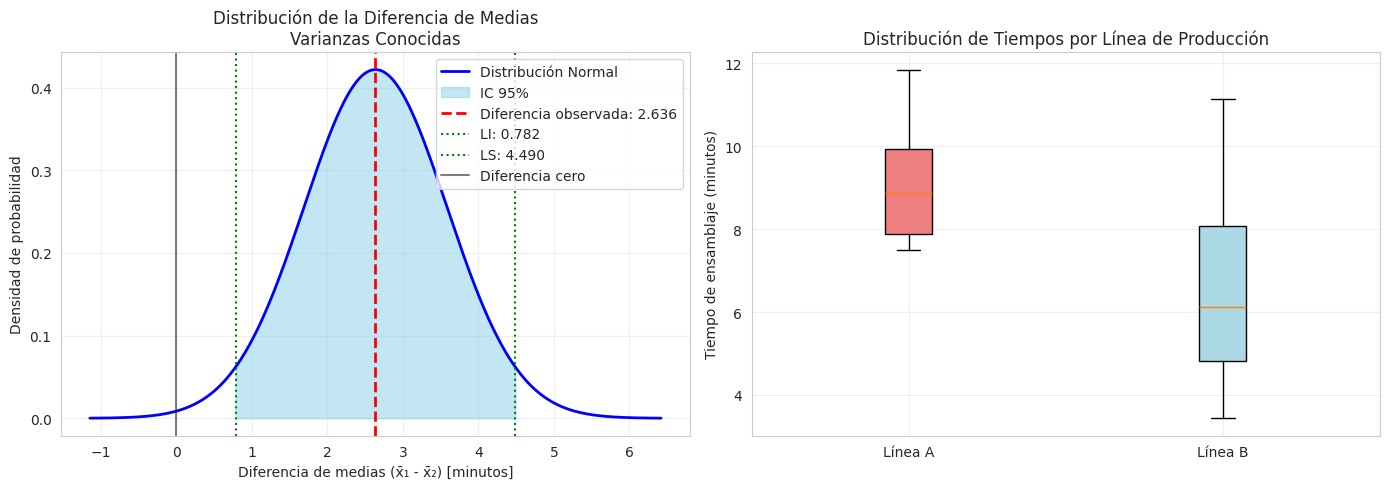


📊 Gráfico guardado como 'caso1_varianzas_conocidas.png'


In [ ]:
# ============================================================
# @title **CÓDIGO PYTHON - INTERVALO DE CONFIANZA CON VARIANZAS CONOCIDAS**
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Configuración
sns.set_style("whitegrid")
np.random.seed(42)

# ==================== DATOS DEL PROBLEMA ====================
n1, n2 = 12, 10                    # Tamaños muestrales
var1_conocida, var2_conocida = 4.5, 5.2   # Varianzas poblacionales conocidas
sigma1, sigma2 = np.sqrt(var1_conocida), np.sqrt(var2_conocida)

# Datos muestrales (tiempos en minutos)
media_pob_A, media_pob_B = 8.5, 7.8
muestra_A = np.random.normal(media_pob_A, sigma1, n1)
muestra_B = np.random.normal(media_pob_B, sigma2, n2)

# Estadísticos muestrales
x1_bar, x2_bar = np.mean(muestra_A), np.mean(muestra_B)
diferencia_obs = x1_bar - x2_bar

# ==================== CÁLCULOS ====================
error_estandar = np.sqrt(var1_conocida/n1 + var2_conocida/n2)
nivel_confianza = 0.95
alpha = 1 - nivel_confianza
z_critico = norm.ppf(1 - alpha/2)

# Intervalo de confianza
li = diferencia_obs - z_critico * error_estandar
ls = diferencia_obs + z_critico * error_estandar

print("="*65)
print("CASO 1: INTERVALO DE CONFIANZA - VARIANZAS CONOCIDAS")
print("="*65)
print(f"\n📊 Estadísticos muestrales:")
print(f"   Media Línea A (x̄₁): {x1_bar:.4f} minutos")
print(f"   Media Línea B (x̄₂): {x2_bar:.4f} minutos")
print(f"   Diferencia observada: {diferencia_obs:.4f} minutos")
print(f"\n📈 Cálculos:")
print(f"   Error estándar: {error_estandar:.4f}")
print(f"   Z crítico (95%): ±{z_critico:.4f}")
print(f"\n🎯 Intervalo de Confianza (95%):")
print(f"   ({li:.4f}, {ls:.4f}) minutos")
print(f"\n💡 Interpretación:")
print(f"   Con un 95% de confianza, la verdadera diferencia de tiempos")
print(f"   se encuentra entre {li:.4f} y {ls:.4f} minutos.")
if li <= 0 <= ls:
    print("   → El intervalo contiene 0. No hay diferencia significativa.")
else:
    print("   → El intervalo NO contiene 0. Las diferencias son significativas.")

# ==================== VISUALIZACIÓN ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución Normal de la diferencia con región sombreada
x = np.linspace(diferencia_obs - 4*error_estandar,
                diferencia_obs + 4*error_estandar, 1000)
y = norm.pdf(x, diferencia_obs, error_estandar)

ax1 = axes[0]
ax1.plot(x, y, 'b-', linewidth=2, label='Distribución Normal')
ax1.fill_between(x, y, where=(x >= li) & (x <= ls),
                  color='skyblue', alpha=0.5, label='IC 95%')
ax1.axvline(diferencia_obs, color='red', linestyle='--', linewidth=2,
            label=f'Diferencia observada: {diferencia_obs:.3f}')
ax1.axvline(li, color='green', linestyle=':', label=f'LI: {li:.3f}')
ax1.axvline(ls, color='green', linestyle=':', label=f'LS: {ls:.3f}')
ax1.axvline(0, color='black', linestyle='-', alpha=0.5, label='Diferencia cero')
ax1.set_xlabel('Diferencia de medias (x̄₁ - x̄₂) [minutos]')
ax1.set_ylabel('Densidad de probabilidad')
ax1.set_title('Distribución de la Diferencia de Medias\nVarianzas Conocidas')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Diagrama de cajas comparativo
ax2 = axes[1]
datos = [muestra_A, muestra_B]
bp = ax2.boxplot(datos, tick_labels=['Línea A', 'Línea B'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax2.set_ylabel('Tiempo de ensamblaje (minutos)')
ax2.set_title('Distribución de Tiempos por Línea de Producción')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('caso1_varianzas_conocidas.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Gráfico guardado como 'caso1_varianzas_conocidas.png'")

[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. CÓDIGO R - INTERVALO DE CONFIANZA CON VARIANZAS CONOCIDAS**


= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
CASO 1: INTERVALO DE CONFIANZA - VARIANZAS CONOCIDAS
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

📊 Estadísticos muestrales:
   Media Línea A (x̄₁): 10.1024 minutos
   Media Línea B (x̄₂): 6.1321 minutos
   Diferencia observada: 3.9702 minutos

📈 Cálculos:
   Error estándar: 0.946 
   Z crítico (95%): ± 1.96 

🎯 Intervalo de Confianza (95%):
   ( 2.116 , 5.8245 ) minutos

📊 Gráfico guardado como 'caso1_varianzas_conocidas_r.png'


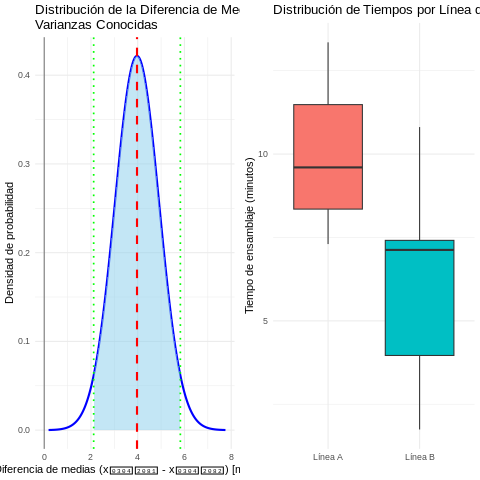

In [ ]:
# ============================================================
# CÓDIGO R - INTERVALO DE CONFIANZA CON VARIANZAS CONOCIDAS
# ============================================================
%%R
# Instalar el paquete gridExtra si no está instalado
if (!requireNamespace("gridExtra", quietly = TRUE)) {
  install.packages("gridExtra")
}

library(ggplot2)
library(gridExtra)
library(dplyr)

set.seed(42)

# ==================== DATOS DEL PROBLEMA ====================
n1 <- 12; n2 <- 10
var1_conocida <- 4.5; var2_conocida <- 5.2
sigma1 <- sqrt(var1_conocida); sigma2 <- sqrt(var2_conocida)

# Datos muestrales
media_pob_A <- 8.5; media_pob_B <- 7.8
muestra_A <- rnorm(n1, media_pob_A, sigma1)
muestra_B <- rnorm(n2, media_pob_B, sigma2)

# Estadísticos
x1_bar <- mean(muestra_A); x2_bar <- mean(muestra_B)
diferencia_obs <- x1_bar - x2_bar

# ==================== CÁLCULOS ====================
error_estandar <- sqrt(var1_conocida/n1 + var2_conocida/n2)
nivel_confianza <- 0.95
z_critico <- qnorm(1 - (1 - nivel_confianza)/2)

li <- diferencia_obs - z_critico * error_estandar
ls <- diferencia_obs + z_critico * error_estandar

# ==================== RESULTADOS ====================
cat("=", rep("=", 63), "\n")
cat("CASO 1: INTERVALO DE CONFIANZA - VARIANZAS CONOCIDAS\n")
cat("=", rep("=", 63), "\n")
cat("\n📊 Estadísticos muestrales:\n")
cat("   Media Línea A (x̄₁):", round(x1_bar, 4), "minutos\n")
cat("   Media Línea B (x̄₂):", round(x2_bar, 4), "minutos\n")
cat("   Diferencia observada:", round(diferencia_obs, 4), "minutos\n")
cat("\n📈 Cálculos:\n")
cat("   Error estándar:", round(error_estandar, 4), "\n")
cat("   Z crítico (95%): ±", round(z_critico, 4), "\n")
cat("\n🎯 Intervalo de Confianza (95%):\n")
cat("   (", round(li, 4), ",", round(ls, 4), ") minutos\n")

# ==================== VISUALIZACIÓN ====================
# Gráfico 1: Distribución Normal
x_norm <- seq(diferencia_obs - 4*error_estandar,
              diferencia_obs + 4*error_estandar, length.out = 1000)
y_norm <- dnorm(x_norm, diferencia_obs, error_estandar)

df_norm <- data.frame(x = x_norm, y = y_norm)

p1 <- ggplot(df_norm, aes(x = x, y = y_norm)) +
  geom_line(color = "blue", linewidth = 1) +
  geom_area(data = subset(df_norm, x >= li & x <= ls),
            aes(x = x, y = y), fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = diferencia_obs, color = "red", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = c(li, ls), color = "green", linetype = "dotted", linewidth = 0.8) +
  geom_vline(xintercept = 0, color = "black", alpha = 0.5) +
  labs(x = "Diferencia de medias (x̄₁ - x̄₂) [minutos]",
       y = "Densidad de probabilidad",
       title = "Distribución de la Diferencia de Medias\nVarianzas Conocidas") +
  theme_minimal()

# Gráfico 2: Diagrama de cajas
datos_df <- data.frame(
  Tiempo = c(muestra_A, muestra_B),
  Linea = factor(rep(c("Línea A", "Línea B"), c(n1, n2)))
)

p2 <- ggplot(datos_df, aes(x = Linea, y = Tiempo, fill = Linea)) +
  geom_boxplot() +
  labs(x = "", y = "Tiempo de ensamblaje (minutos)",
       title = "Distribución de Tiempos por Línea de Producción") +
  theme_minimal() +
  theme(legend.position = "none")

# Combinar
grid.arrange(p1, p2, ncol = 2)
ggsave("caso1_varianzas_conocidas_r.png",
       arrangeGrob(p1, p2, ncol = 2), width = 14, height = 6, dpi = 150)
cat("\n📊 Gráfico guardado como 'caso1_varianzas_conocidas_r.png'\n")

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. CASO 2: VARIANZAS DESCONOCIDAS PERO IGUALES - Contexto: Ciencias Económicas - Evaluación de Políticas Salariales**


**PROBLEMA: Comparación de Salarios por Género
Un estudio económico evalúa si existe diferencia salarial entre hombres y mujeres en una empresa del sector financiero. Se asume que las varianzas poblacionales son desconocidas pero iguales. Muestras pequeñas: n₁ = 15 mujeres, n₂ = 12 hombres.**



CASO 2: INTERVALO DE CONFIANZA - VARIANZAS DESCONOCIDAS PERO IGUALES

📊 Estadísticos muestrales:
   Media Mujeres (x̄₁): 46.98 miles $
   Media Hombres (x̄₂): 54.85 miles $
   Diferencia (Mujeres - Hombres): -7.87 miles $

📈 Cálculos:
   Varianza combinada (s_p²): 33.6163
   Desviación combinada (s_p): 5.7980
   Error estándar: 2.2455
   Grados de libertad: 25
   t crítico (95%): ±2.0595

🎯 Intervalo de Confianza (95%):
   (-12.49, -3.24) miles de pesos

💡 Interpretación:
   → El intervalo NO contiene 0. La diferencia es significativa.


/tmp/ipykernel_27274/349229799.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(datos_salarios, labels=['Mujeres', 'Hombres'], patch_artist=True)


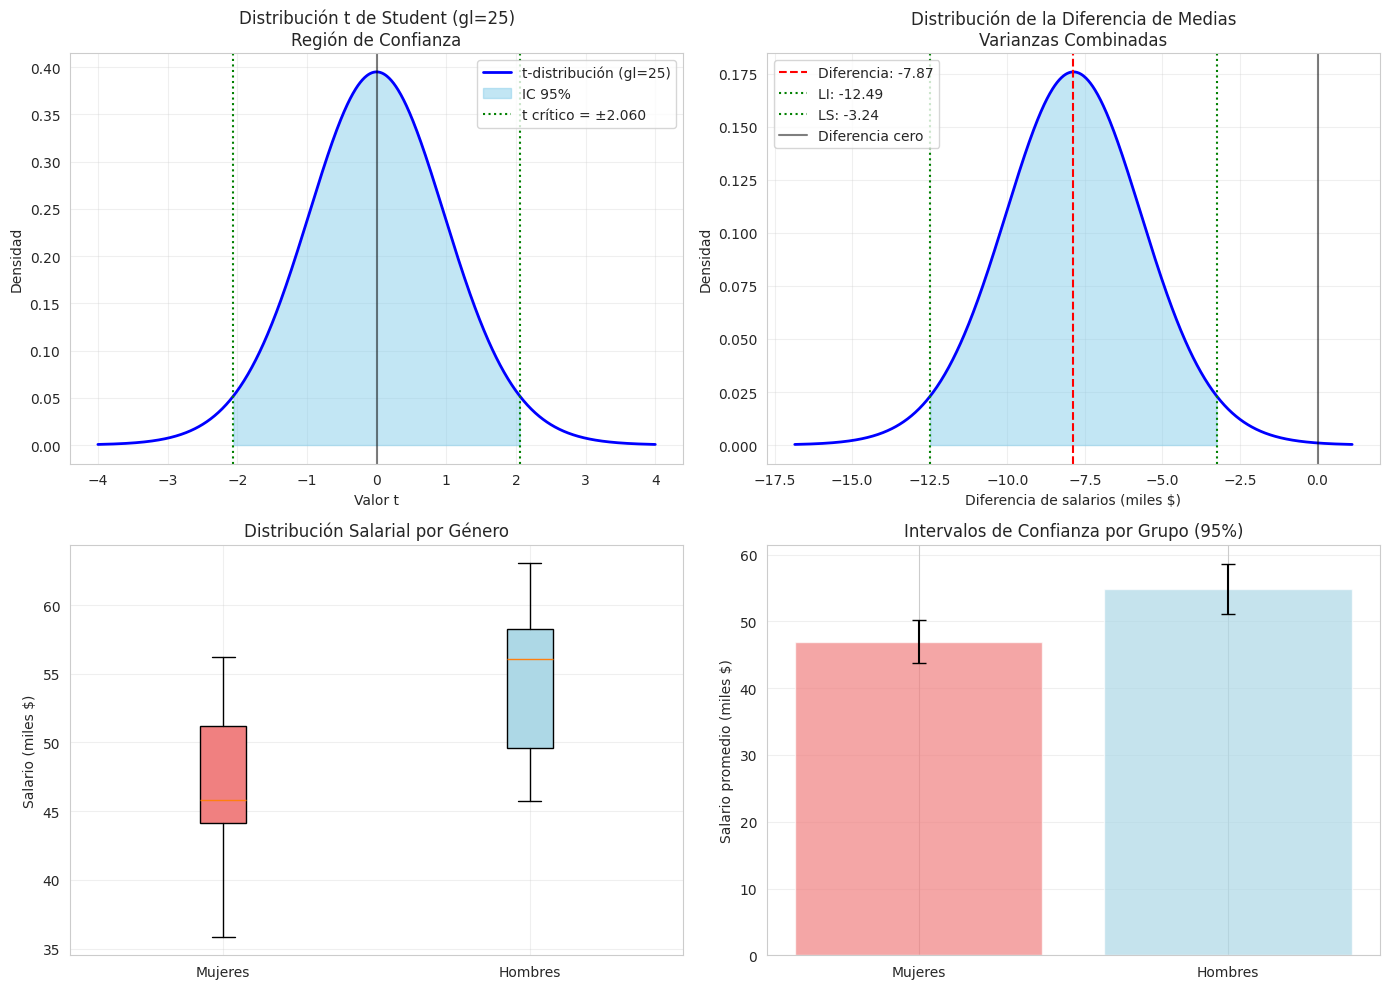


📊 Gráfico guardado como 'caso2_varianzas_iguales.png'


In [ ]:
# ============================================================
# CÓDIGO PYTHON - VARIANZAS DESCONOCIDAS PERO IGUALES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t
import seaborn as sns

# Configuración
np.random.seed(123)
sns.set_style("whitegrid")

# ==================== DATOS DEL PROBLEMA ====================
n_mujeres, n_hombres = 15, 12
varianza_poblacional_comun = 25

# Generar datos (salarios en miles de pesos)
media_mujeres, media_hombres = 48, 52
desv_est = np.sqrt(varianza_poblacional_comun)

salarios_mujeres = np.random.normal(media_mujeres, desv_est, n_mujeres)
salarios_hombres = np.random.normal(media_hombres, desv_est, n_hombres)

# Estadísticos muestrales
x1_bar, x2_bar = np.mean(salarios_mujeres), np.mean(salarios_hombres)
s1_cuad, s2_cuad = np.var(salarios_mujeres, ddof=1), np.var(salarios_hombres, ddof=1)

# ==================== CÁLCULOS ====================
# Varianza combinada
s_p_cuad = ((n_mujeres - 1) * s1_cuad + (n_hombres - 1) * s2_cuad) / (n_mujeres + n_hombres - 2)
s_p = np.sqrt(s_p_cuad)

# Error estándar
error_estandar = s_p * np.sqrt(1/n_mujeres + 1/n_hombres)

# Grados de libertad y valor crítico
gl = n_mujeres + n_hombres - 2
nivel_confianza = 0.95
t_critico = t.ppf(1 - (1 - nivel_confianza)/2, gl)

# Diferencia e intervalo
diferencia = x1_bar - x2_bar
li = diferencia - t_critico * error_estandar
ls = diferencia + t_critico * error_estandar

print("="*65)
print("CASO 2: INTERVALO DE CONFIANZA - VARIANZAS DESCONOCIDAS PERO IGUALES")
print("="*65)
print(f"\n📊 Estadísticos muestrales:")
print(f"   Media Mujeres (x̄₁): {x1_bar:.2f} miles $")
print(f"   Media Hombres (x̄₂): {x2_bar:.2f} miles $")
print(f"   Diferencia (Mujeres - Hombres): {diferencia:.2f} miles $")
print(f"\n📈 Cálculos:")
print(f"   Varianza combinada (s_p²): {s_p_cuad:.4f}")
print(f"   Desviación combinada (s_p): {s_p:.4f}")
print(f"   Error estándar: {error_estandar:.4f}")
print(f"   Grados de libertad: {gl}")
print(f"   t crítico (95%): ±{t_critico:.4f}")
print(f"\n🎯 Intervalo de Confianza (95%):")
print(f"   ({li:.2f}, {ls:.2f}) miles de pesos")
print(f"\n💡 Interpretación:")
if li <= 0 <= ls:
    print("   → El intervalo contiene 0. No hay diferencia salarial significativa.")
else:
    print("   → El intervalo NO contiene 0. La diferencia es significativa.")

# ==================== VISUALIZACIÓN ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución t
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, gl)

ax1 = axes[0, 0]
ax1.plot(x_t, y_t, 'b-', linewidth=2, label=f't-distribución (gl={gl})')
ax1.fill_between(x_t, y_t, where=(x_t >= -t_critico) & (x_t <= t_critico),
                  color='skyblue', alpha=0.5, label=f'IC 95%')
ax1.axvline(0, color='black', alpha=0.5)
ax1.axvline(t_critico, color='green', linestyle=':', label=f't crítico = ±{t_critico:.3f}')
ax1.axvline(-t_critico, color='green', linestyle=':')
ax1.set_xlabel('Valor t')
ax1.set_ylabel('Densidad')
ax1.set_title(f'Distribución t de Student (gl={gl})\nRegión de Confianza')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de la diferencia
x_diff = np.linspace(diferencia - 4*error_estandar,
                     diferencia + 4*error_estandar, 1000)
y_diff = t.pdf((x_diff - diferencia)/error_estandar, gl) / error_estandar

ax2 = axes[0, 1]
ax2.plot(x_diff, y_diff, 'b-', linewidth=2)
ax2.fill_between(x_diff, y_diff, where=(x_diff >= li) & (x_diff <= ls),
                  color='skyblue', alpha=0.5)
ax2.axvline(diferencia, color='red', linestyle='--', label=f'Diferencia: {diferencia:.2f}')
ax2.axvline(li, color='green', linestyle=':', label=f'LI: {li:.2f}')
ax2.axvline(ls, color='green', linestyle=':', label=f'LS: {ls:.2f}')
ax2.axvline(0, color='black', alpha=0.5, label='Diferencia cero')
ax2.set_xlabel('Diferencia de salarios (miles $)')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de la Diferencia de Medias\nVarianzas Combinadas')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Diagrama de cajas
ax3 = axes[1, 0]
datos_salarios = [salarios_mujeres, salarios_hombres]
bp = ax3.boxplot(datos_salarios, labels=['Mujeres', 'Hombres'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax3.set_ylabel('Salario (miles $)')
ax3.set_title('Distribución Salarial por Género')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Intervalos individuales
ax4 = axes[1, 1]
grupos = ['Mujeres', 'Hombres']
medias = [x1_bar, x2_bar]
errores = [np.sqrt(s1_cuad/n_mujeres), np.sqrt(s2_cuad/n_hombres)]
t_val = t.ppf(0.975, [n_mujeres-1, n_hombres-1])

ax4.bar(grupos, medias, yerr=[t_val[i]*errores[i] for i in range(2)],
        color=['lightcoral', 'lightblue'], capsize=5, alpha=0.7)
ax4.set_ylabel('Salario promedio (miles $)')
ax4.set_title('Intervalos de Confianza por Grupo (95%)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('caso2_varianzas_iguales.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Gráfico guardado como 'caso2_varianzas_iguales.png'")

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. CÓDIGO R - VARIANZAS DESCONOCIDAS PERO IGUALES**


In [ ]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython



 = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
CASO 2: INTERVALO DE CONFIANZA - VARIANZAS IGUALES
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

📊 Diferencia observada: -1.58 miles $
📈 Error estándar: 1.8745 
🎯 IC 95%: ( -5.45 , 2.28 ) miles $

📊 Gráfico guardado como 'caso2_varianzas_iguales_r.png'


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.tar.gz'
Content type 'application/x-gzip' length 1062844 bytes (1.0 MB)
downloaded 1.0 MB


The downloaded source packages are in
	‘/tmp/Rtmp4wnibK/downloaded_packages’


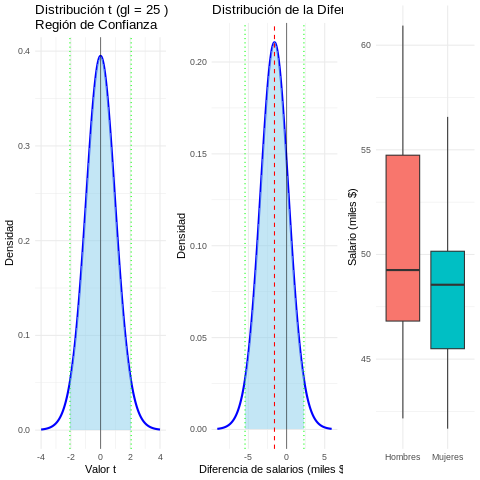

In [ ]:
# ============================================================
# CÓDIGO R - VARIANZAS DESCONOCIDAS PERO IGUALES
# ============================================================
%%R
# Instalar el paquete gridExtra si no está instalado
if (!requireNamespace("gridExtra", quietly = TRUE)) {
  install.packages("gridExtra")
}

library(ggplot2)
library(gridExtra)

set.seed(123)

# ==================== DATOS DEL PROBLEMA ====================
n_mujeres <- 15; n_hombres <- 12
media_mujeres <- 48; media_hombres <- 52
desv_est <- 5

salarios_mujeres <- rnorm(n_mujeres, media_mujeres, desv_est)
salarios_hombres <- rnorm(n_hombres, media_hombres, desv_est)

# Estadísticos
x1_bar <- mean(salarios_mujeres); x2_bar <- mean(salarios_hombres)
s1_cuad <- var(salarios_mujeres); s2_cuad <- var(salarios_hombres)

# ==================== CÁLCULOS ====================
s_p_cuad <- ((n_mujeres - 1) * s1_cuad + (n_hombres - 1) * s2_cuad) / (n_mujeres + n_hombres - 2)
s_p <- sqrt(s_p_cuad)
error_estandar <- s_p * sqrt(1/n_mujeres + 1/n_hombres)
gl <- n_mujeres + n_hombres - 2
t_critico <- qt(0.975, gl)
diferencia <- x1_bar - x2_bar
li <- diferencia - t_critico * error_estandar
ls <- diferencia + t_critico * error_estandar

# ==================== RESULTADOS ====================
cat("\n", rep("=", 65), "\n")
cat("CASO 2: INTERVALO DE CONFIANZA - VARIANZAS IGUALES\n")
cat(rep("=", 65), "\n")
cat("\n📊 Diferencia observada:", round(diferencia, 2), "miles $\n")
cat("📈 Error estándar:", round(error_estandar, 4), "\n")
cat("🎯 IC 95%: (", round(li, 2), ",", round(ls, 2), ") miles $\n")

# ==================== VISUALIZACIÓN ====================
# Gráfico 1: Distribución t
x_t <- seq(-4, 4, length.out = 1000)
y_t <- dt(x_t, gl)
df_t <- data.frame(x = x_t, y = y_t)

p1 <- ggplot(df_t, aes(x = x, y = y_t)) +
  geom_line(color = "blue", linewidth = 1) +
  geom_area(data = subset(df_t, x >= -t_critico & x <= t_critico),
            aes(x = x, y = y), fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = 0, color = "black", alpha = 0.5) +
  geom_vline(xintercept = c(-t_critico, t_critico), color = "green", linetype = "dotted") +
  labs(x = "Valor t", y = "Densidad",
       title = paste("Distribución t (gl =", gl, ")\nRegión de Confianza")) +
  theme_minimal()

# Gráfico 2: Diferencia
x_diff <- seq(diferencia - 4*error_estandar, diferencia + 4*error_estandar, length.out = 1000)
y_diff <- dt((x_diff - diferencia)/error_estandar, gl) / error_estandar
df_diff <- data.frame(x = x_diff, y = y_diff)

p2 <- ggplot(df_diff, aes(x = x, y = y_diff)) +
  geom_line(color = "blue", linewidth = 1) +
  geom_area(data = subset(df_diff, x >= li & x <= ls), aes(x = x, y = y), fill = "skyblue", alpha = 0.5) +
  geom_vline(xintercept = diferencia, color = "red", linetype = "dashed") +
  geom_vline(xintercept = c(li, ls), color = "green", linetype = "dotted") +
  geom_vline(xintercept = 0, color = "black", alpha = 0.5) +
  labs(x = "Diferencia de salarios (miles $)", y = "Densidad",
       title = "Distribución de la Diferencia de Medias") +
  theme_minimal()

# Gráfico 3: Boxplot
datos_df <- data.frame(
  Salario = c(salarios_mujeres, salarios_hombres),
  Genero = factor(rep(c("Mujeres", "Hombres"), c(n_mujeres, n_hombres)))
)

p3 <- ggplot(datos_df, aes(x = Genero, y = Salario, fill = Genero)) +
  geom_boxplot() + labs(x = "", y = "Salario (miles $)") +
  theme_minimal() + theme(legend.position = "none")

# Combinar
grid.arrange(p1, p2, p3, ncol = 3, widths = c(1, 1, 0.8))
ggsave("caso2_varianzas_iguales_r.png",
       arrangeGrob(p1, p2, p3, ncol = 3), width = 16, height = 6, dpi = 150)
cat("\n📊 Gráfico guardado como 'caso2_varianzas_iguales_r.png'\n")

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **5. CASO 3: VARIANZAS DESCONOCIDAS Y DIFERENTES - Contexto: Ciencias Sociales - Evaluación de Programas Educativos**




**PROBLEMA: Comparación de Métodos de Enseñanza
Un estudio en psicología educativa compara dos métodos de enseñanza (tradicional vs. innovador). Las varianzas poblacionales son desconocidas y se asumen diferentes. Muestras pequeñas: n₁ = 10 (tradicional), n₂ = 12 (innovador).**

CASO 3: INTERVALO DE CONFIANZA - VARIANZAS DESCONOCIDAS Y DIFERENTES

📊 Estadísticos muestrales:
   Media Tradicional (x̄₁): 74.97 puntos
   Media Innovador (x̄₂): 78.88 puntos
   Diferencia (Tradicional - Innovador): -3.90 puntos

📈 Cálculos:
   Varianza tradicional (s₁²): 38.6600
   Varianza innovador (s₂²): 30.9652
   Error estándar (Welch): 2.5390
   Grados de libertad (Satterthwaite): 18.34
   t crítico (95%): ±2.0981

🎯 Intervalo de Confianza (95%):
   (-9.23, 1.42) puntos

💡 Interpretación:
   → El intervalo contiene 0. No hay diferencia significativa entre métodos.


/tmp/ipykernel_27274/642032187.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(datos_puntajes, labels=['Tradicional', 'Innovador'], patch_artist=True)


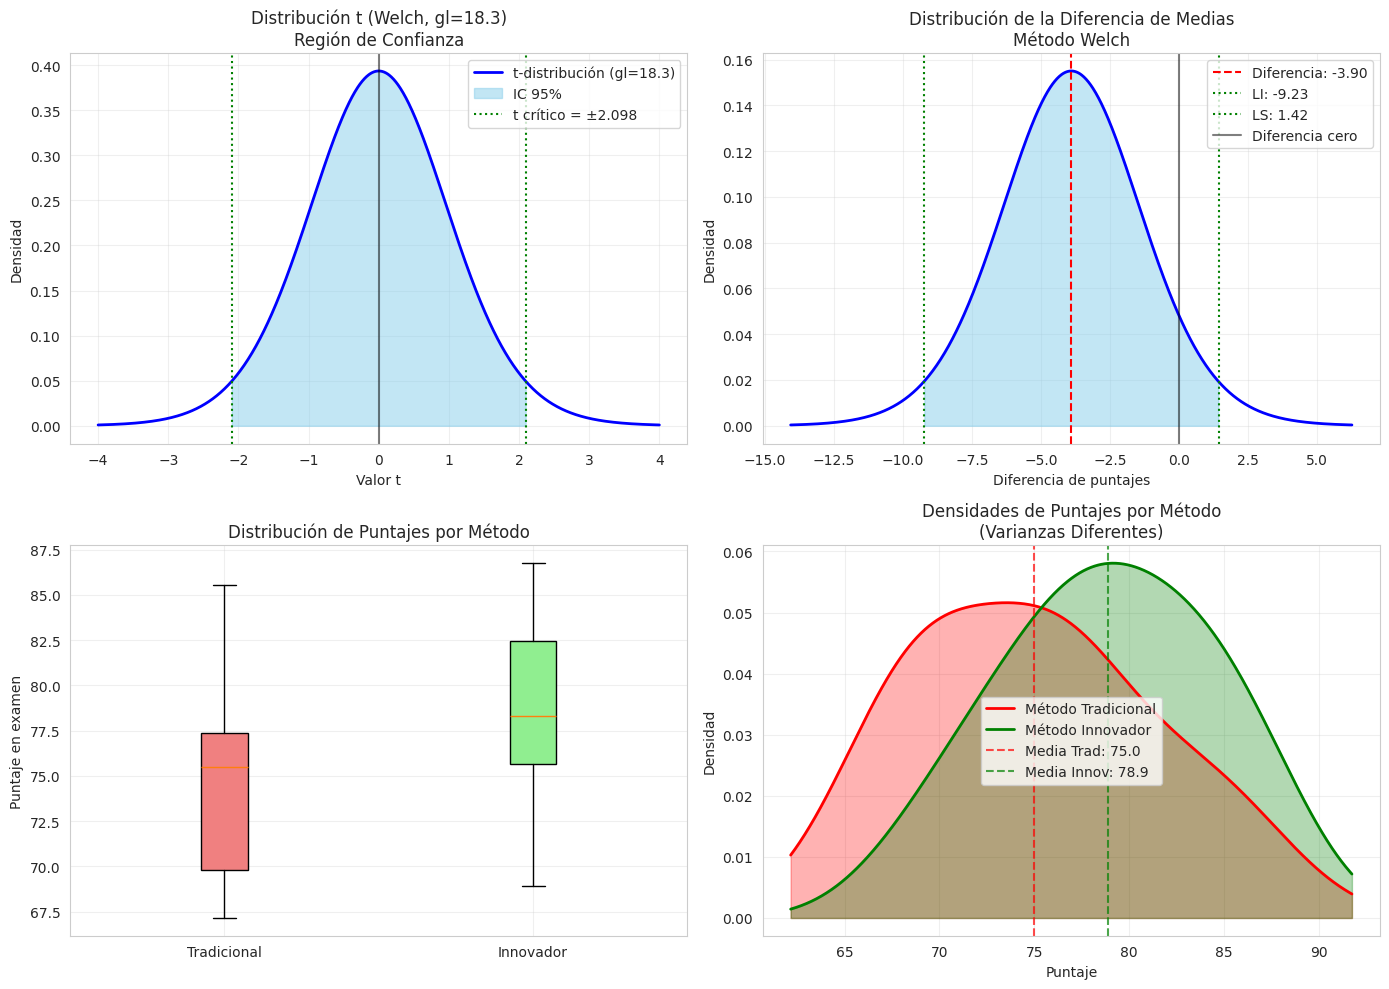


📊 Gráfico guardado como 'caso3_varianzas_diferentes.png'


In [ ]:
# ============================================================
# CÓDIGO PYTHON - VARIANZAS DESCONOCIDAS Y DIFERENTES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t
import seaborn as sns

# Configuración
np.random.seed(456)
sns.set_style("whitegrid")

# ==================== DATOS DEL PROBLEMA ====================
n_trad, n_innov = 10, 12
media_trad, media_innov = 72.5, 78.0
desv_trad, desv_innov = 8.0, 4.5

puntajes_trad = np.random.normal(media_trad, desv_trad, n_trad)
puntajes_innov = np.random.normal(media_innov, desv_innov, n_innov)

# Estadísticos muestrales
x1_bar, x2_bar = np.mean(puntajes_trad), np.mean(puntajes_innov)
s1_cuad, s2_cuad = np.var(puntajes_trad, ddof=1), np.var(puntajes_innov, ddof=1)

# ==================== CÁLCULOS (MÉTODO WELCH) ====================
diferencia = x1_bar - x2_bar
error_estandar = np.sqrt(s1_cuad/n_trad + s2_cuad/n_innov)

# Grados de libertad Satterthwaite
gl = (s1_cuad/n_trad + s2_cuad/n_innov)**2 / (
    (s1_cuad/n_trad)**2/(n_trad - 1) + (s2_cuad/n_innov)**2/(n_innov - 1)
)

nivel_confianza = 0.95
t_critico = t.ppf(1 - (1 - nivel_confianza)/2, gl)

li = diferencia - t_critico * error_estandar
ls = diferencia + t_critico * error_estandar

print("="*65)
print("CASO 3: INTERVALO DE CONFIANZA - VARIANZAS DESCONOCIDAS Y DIFERENTES")
print("="*65)
print(f"\n📊 Estadísticos muestrales:")
print(f"   Media Tradicional (x̄₁): {x1_bar:.2f} puntos")
print(f"   Media Innovador (x̄₂): {x2_bar:.2f} puntos")
print(f"   Diferencia (Tradicional - Innovador): {diferencia:.2f} puntos")
print(f"\n📈 Cálculos:")
print(f"   Varianza tradicional (s₁²): {s1_cuad:.4f}")
print(f"   Varianza innovador (s₂²): {s2_cuad:.4f}")
print(f"   Error estándar (Welch): {error_estandar:.4f}")
print(f"   Grados de libertad (Satterthwaite): {gl:.2f}")
print(f"   t crítico (95%): ±{t_critico:.4f}")
print(f"\n🎯 Intervalo de Confianza (95%):")
print(f"   ({li:.2f}, {ls:.2f}) puntos")
print(f"\n💡 Interpretación:")
if li <= 0 <= ls:
    print("   → El intervalo contiene 0. No hay diferencia significativa entre métodos.")
else:
    print("   → El intervalo NO contiene 0. La diferencia es significativa.")

# ==================== VISUALIZACIÓN ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución t
x_t = np.linspace(-4, 4, 1000)
y_t = t.pdf(x_t, gl)

ax1 = axes[0, 0]
ax1.plot(x_t, y_t, 'b-', linewidth=2, label=f't-distribución (gl={gl:.1f})')
ax1.fill_between(x_t, y_t, where=(x_t >= -t_critico) & (x_t <= t_critico),
                  color='skyblue', alpha=0.5, label=f'IC 95%')
ax1.axvline(0, color='black', alpha=0.5)
ax1.axvline(t_critico, color='green', linestyle=':', label=f't crítico = ±{t_critico:.3f}')
ax1.axvline(-t_critico, color='green', linestyle=':')
ax1.set_xlabel('Valor t')
ax1.set_ylabel('Densidad')
ax1.set_title(f'Distribución t (Welch, gl={gl:.1f})\nRegión de Confianza')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de la diferencia
x_diff = np.linspace(diferencia - 4*error_estandar,
                     diferencia + 4*error_estandar, 1000)
y_diff = t.pdf((x_diff - diferencia)/error_estandar, gl) / error_estandar

ax2 = axes[0, 1]
ax2.plot(x_diff, y_diff, 'b-', linewidth=2)
ax2.fill_between(x_diff, y_diff, where=(x_diff >= li) & (x_diff <= ls),
                  color='skyblue', alpha=0.5)
ax2.axvline(diferencia, color='red', linestyle='--', label=f'Diferencia: {diferencia:.2f}')
ax2.axvline(li, color='green', linestyle=':', label=f'LI: {li:.2f}')
ax2.axvline(ls, color='green', linestyle=':', label=f'LS: {ls:.2f}')
ax2.axvline(0, color='black', alpha=0.5, label='Diferencia cero')
ax2.set_xlabel('Diferencia de puntajes')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de la Diferencia de Medias\nMétodo Welch')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Diagrama de cajas
ax3 = axes[1, 0]
datos_puntajes = [puntajes_trad, puntajes_innov]
bp = ax3.boxplot(datos_puntajes, labels=['Tradicional', 'Innovador'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
ax3.set_ylabel('Puntaje en examen')
ax3.set_title('Distribución de Puntajes por Método')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Densidades superpuestas
ax4 = axes[1, 1]
from scipy.stats import gaussian_kde
x_dens = np.linspace(min(np.min(puntajes_trad), np.min(puntajes_innov)) - 5,
                     max(np.max(puntajes_trad), np.max(puntajes_innov)) + 5, 1000)

kde_trad = gaussian_kde(puntajes_trad)
kde_innov = gaussian_kde(puntajes_innov)

ax4.plot(x_dens, kde_trad(x_dens), 'r-', linewidth=2, label='Método Tradicional')
ax4.fill_between(x_dens, kde_trad(x_dens), alpha=0.3, color='red')
ax4.plot(x_dens, kde_innov(x_dens), 'g-', linewidth=2, label='Método Innovador')
ax4.fill_between(x_dens, kde_innov(x_dens), alpha=0.3, color='green')
ax4.axvline(x1_bar, color='red', linestyle='--', alpha=0.7, label=f'Media Trad: {x1_bar:.1f}')
ax4.axvline(x2_bar, color='green', linestyle='--', alpha=0.7, label=f'Media Innov: {x2_bar:.1f}')
ax4.set_xlabel('Puntaje')
ax4.set_ylabel('Densidad')
ax4.set_title('Densidades de Puntajes por Método\n(Varianzas Diferentes)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('caso3_varianzas_diferentes.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Gráfico guardado como 'caso3_varianzas_diferentes.png'")

[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. CASO 4: COCIENTE DE VARIANZAS (PRUEBA F) - Contexto: Ingeniería de Procesos - Control de Variabilidad**


**PROBLEMA: Comparación de Variabilidad entre Máquinas
Un ingeniero de procesos evalúa si dos máquinas de llenado tienen variabilidad diferente en el volumen de producto. Se construye un intervalo de confianza para el cociente de varianzas σ₁²/σ₂². Muestras pequeñas: n₁ = 10, n₂ = 8.**

CASO 4: INTERVALO DE CONFIANZA PARA COCIENTE DE VARIANZAS

📊 Estadísticos muestrales:
   Varianza Máquina 1 (s₁²): 106.9965 ml²
   Varianza Máquina 2 (s₂²): 37.0345 ml²
   Cociente observado (s₁²/s₂²): 2.8891

📈 Cálculos:
   Grados de libertad: ν₁ = 9, ν₂ = 7
   F crítico inferior (2.5%): 0.2383
   F crítico superior (97.5%): 4.8232

🎯 Intervalo de Confianza (95%) para σ₁²/σ₂²:
   (0.5990, 12.1257)

🎯 Intervalo de Confianza (95%) para σ₁/σ₂:
   (0.7740, 3.4822)

💡 Interpretación:
   → El intervalo contiene 1. No hay evidencia de que las varianzas sean diferentes.


/tmp/ipykernel_27274/1005593126.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(datos_volumen, labels=['Máquina 1', 'Máquina 2'], patch_artist=True)


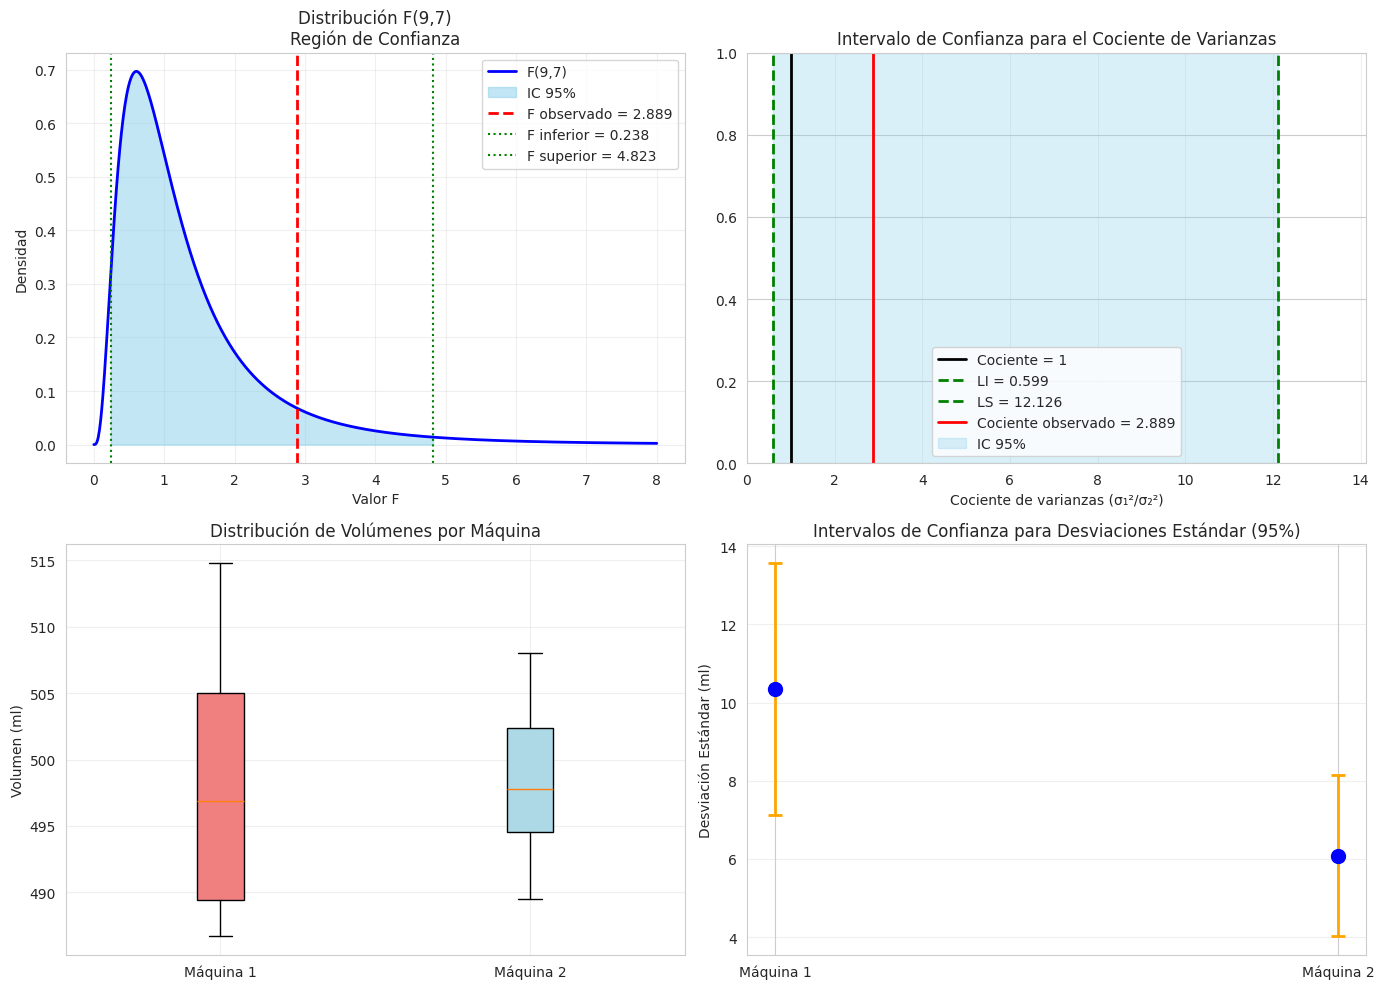


📊 Gráfico guardado como 'caso4_cociente_varianzas.png'


In [ ]:
# ============================================================
# CÓDIGO PYTHON - COCIENTE DE VARIANZAS (INTERVALO F)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f
import seaborn as sns

# Configuración
np.random.seed(789)
sns.set_style("whitegrid")

# ==================== DATOS DEL PROBLEMA ====================
n_maq1, n_maq2 = 10, 8
media_maq1, media_maq2 = 500, 500
desv_maq1, desv_maq2 = 12, 6

volumen_maq1 = np.random.normal(media_maq1, desv_maq1, n_maq1)
volumen_maq2 = np.random.normal(media_maq2, desv_maq2, n_maq2)

# Estadísticos muestrales
var1 = np.var(volumen_maq1, ddof=1)
var2 = np.var(volumen_maq2, ddof=1)

# ==================== CÁLCULOS ====================
f_obs = var1 / var2
gl1 = n_maq1 - 1
gl2 = n_maq2 - 1

nivel_confianza = 0.95
alpha = 1 - nivel_confianza

f_inferior = f.ppf(alpha/2, gl1, gl2)
f_superior = f.ppf(1 - alpha/2, gl1, gl2)

# Intervalo para cociente de varianzas
li_ratio = f_obs / f_superior
ls_ratio = f_obs / f_inferior

# Intervalo para desviaciones
li_sd = np.sqrt(li_ratio)
ls_sd = np.sqrt(ls_ratio)

print("="*65)
print("CASO 4: INTERVALO DE CONFIANZA PARA COCIENTE DE VARIANZAS")
print("="*65)
print(f"\n📊 Estadísticos muestrales:")
print(f"   Varianza Máquina 1 (s₁²): {var1:.4f} ml²")
print(f"   Varianza Máquina 2 (s₂²): {var2:.4f} ml²")
print(f"   Cociente observado (s₁²/s₂²): {f_obs:.4f}")
print(f"\n📈 Cálculos:")
print(f"   Grados de libertad: ν₁ = {gl1}, ν₂ = {gl2}")
print(f"   F crítico inferior (2.5%): {f_inferior:.4f}")
print(f"   F crítico superior (97.5%): {f_superior:.4f}")
print(f"\n🎯 Intervalo de Confianza (95%) para σ₁²/σ₂²:")
print(f"   ({li_ratio:.4f}, {ls_ratio:.4f})")
print(f"\n🎯 Intervalo de Confianza (95%) para σ₁/σ₂:")
print(f"   ({li_sd:.4f}, {ls_sd:.4f})")
print(f"\n💡 Interpretación:")
if li_ratio <= 1 <= ls_ratio:
    print("   → El intervalo contiene 1. No hay evidencia de que las varianzas sean diferentes.")
else:
    print("   → El intervalo NO contiene 1. Las varianzas son significativamente diferentes.")

# ==================== VISUALIZACIÓN ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución F
x = np.linspace(0, max(8, f_superior + 2), 1000)
y = f.pdf(x, gl1, gl2)

ax1 = axes[0, 0]
ax1.plot(x, y, 'b-', linewidth=2, label=f'F({gl1},{gl2})')
ax1.fill_between(x, y, where=(x >= f_inferior) & (x <= f_superior),
                  color='skyblue', alpha=0.5, label=f'IC {nivel_confianza*100:.0f}%')
ax1.axvline(f_obs, color='red', linestyle='--', linewidth=2,
            label=f'F observado = {f_obs:.3f}')
ax1.axvline(f_inferior, color='green', linestyle=':', label=f'F inferior = {f_inferior:.3f}')
ax1.axvline(f_superior, color='green', linestyle=':', label=f'F superior = {f_superior:.3f}')
ax1.set_xlabel('Valor F')
ax1.set_ylabel('Densidad')
ax1.set_title(f'Distribución F({gl1},{gl2})\nRegión de Confianza')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Intervalo de confianza para el cociente
ax2 = axes[0, 1]
ax2.axvline(1, color='black', linestyle='-', linewidth=2, label='Cociente = 1')
ax2.axvline(li_ratio, color='green', linestyle='--', linewidth=2,
            label=f'LI = {li_ratio:.3f}')
ax2.axvline(ls_ratio, color='green', linestyle='--', linewidth=2,
            label=f'LS = {ls_ratio:.3f}')
ax2.axvline(f_obs, color='red', linestyle='-', linewidth=2,
            label=f'Cociente observado = {f_obs:.3f}')
ax2.fill_betweenx([0, 1], li_ratio, ls_ratio, alpha=0.3, color='skyblue',
                   label=f'IC {nivel_confianza*100:.0f}%')
ax2.set_xlim(max(0, li_ratio - 2), ls_ratio + 2)
ax2.set_ylim(0, 1)
ax2.set_xlabel('Cociente de varianzas (σ₁²/σ₂²)')
ax2.set_title('Intervalo de Confianza para el Cociente de Varianzas')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

# Gráfico 3: Diagrama de cajas
ax3 = axes[1, 0]
datos_volumen = [volumen_maq1, volumen_maq2]
bp = ax3.boxplot(datos_volumen, labels=['Máquina 1', 'Máquina 2'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax3.set_ylabel('Volumen (ml)')
ax3.set_title('Distribución de Volúmenes por Máquina')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Intervalos de confianza para desviaciones
ax4 = axes[1, 1]

chi2_inf1 = stats.chi2.ppf(alpha/2, gl1)
chi2_sup1 = stats.chi2.ppf(1 - alpha/2, gl1)
chi2_inf2 = stats.chi2.ppf(alpha/2, gl2)
chi2_sup2 = stats.chi2.ppf(1 - alpha/2, gl2)

ic_sd1 = (np.sqrt(gl1 * var1 / chi2_sup1), np.sqrt(gl1 * var1 / chi2_inf1))
ic_sd2 = (np.sqrt(gl2 * var2 / chi2_sup2), np.sqrt(gl2 * var2 / chi2_inf2))

maquinas = ['Máquina 1', 'Máquina 2']
desv_est = [np.sqrt(var1), np.sqrt(var2)]
ic_inf = [ic_sd1[0], ic_sd2[0]]
ic_sup = [ic_sd1[1], ic_sd2[1]]

ax4.errorbar(maquinas, desv_est, yerr=[desv_est[i] - ic_inf[i] for i in range(2)],
             fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=10,
             color='blue', ecolor='orange')
ax4.set_ylabel('Desviación Estándar (ml)')
ax4.set_title('Intervalos de Confianza para Desviaciones Estándar (95%)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('caso4_cociente_varianzas.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Gráfico guardado como 'caso4_cociente_varianzas.png'")

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. **




[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. **

+

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. **


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. **


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. **




[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. **


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO